In [58]:
from google.colab import userdata
OPENROUTER_API_KEY=userdata.get('OPENROUTER_API_KEY')
import os
import numpy as np
import pandas as pd
os.environ["OPENROUTER_API_KEY"] = OPENROUTER_API_KEY

In [59]:
import requests

# Replace <YOUR_OPENROUTER_API_KEY> with your actual API key
# It's recommended to store API keys securely, e.g., using environment variables or Colab's Secrets feature.
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY") # TODO: Replace with your actual key

response = requests.post(
  "https://openrouter.ai/api/v1/embeddings",
  headers={
    "Authorization": f"Bearer {OPENROUTER_API_KEY}",
    "Content-Type": "application/json",
  },
  json={
    "model": "openai/text-embedding-3-small",
    "input": "The quick brown fox jumps over the lazy dog"
  }
)

data = response.json()

# Check if the API call was successful before attempting to access 'data'
if response.status_code == 200 and "data" in data:
    embedding = data["data"][0]["embedding"]
    print(f"Embedding dimension: {len(embedding)}")
else:
    print(f"API request failed with status code {response.status_code}")
    print(f"Error response: {data}")
    print("Please ensure your OPENROUTER_API_KEY is correct and has the necessary permissions.")

Embedding dimension: 1536


In [60]:
import requests
import os

def get_embeddings(texto):
  # Obtém a chave da API OpenRouter das variáveis de ambiente
  OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

  # Verifica se a chave da API está configurada
  if not OPENROUTER_API_KEY:
    print("Erro: OPENROUTER_API_KEY não está configurada. Certifique-se de que ela seja carregada dos segredos do Colab ou variáveis de ambiente.")
    return None

  # Faz a requisição POST para a API de embeddings da OpenRouter
  response = requests.post(
    "https://openrouter.ai/api/v1/embeddings",
    headers={
      "Authorization": f"Bearer {OPENROUTER_API_KEY}",
      "Content-Type": "application/json",
    },
    json={
      "model": "openai/text-embedding-3-small",
      "input": texto
    }
  )

  # Converte a resposta para JSON
  data = response.json()

  # Verifica se a chamada da API foi bem-sucedida antes de tentar acessar 'data'
  if response.status_code == 200 and "data" in data:
      # Retorna o embedding gerado
      return data["data"][0]["embedding"]
  else:
      # Imprime a mensagem de erro se a chamada da API falhar
      print(f"A requisição da API falhou com o código de status {response.status_code}")
      print(f"Resposta de erro: {data}")
      print("Por favor, verifique se sua OPENROUTER_API_KEY está correta e tem as permissões necessárias.")
      return None

## Tokens gastos

In [61]:
if 'usage' in data:
    prompt_tokens = data['usage'].get('prompt_tokens')
    total_tokens = data['usage'].get('total_tokens')
    cost = data['usage'].get('cost')
    print(f"Prompt Tokens: {prompt_tokens}")
    print(f"Total Tokens: {total_tokens}")
    print(f"Cost: {cost}")
else:
    print("Informações de uso de tokens não encontradas na resposta da API.")

Prompt Tokens: 9
Total Tokens: 9
Cost: 1.8e-07


In [63]:
import math

def distancia_cosseno(embedding1, embedding2):
    if len(embedding1) != len(embedding2):
        raise ValueError("Os embeddings devem ter o mesmo tamanho.")

    # Produto escalar
    produto = sum(a * b for a, b in zip(embedding1, embedding2))

    # Norma dos vetores
    norma1 = math.sqrt(sum(a**2 for a in embedding1))
    norma2 = math.sqrt(sum(b**2 for b in embedding2))

    # Retorna a similaridade do cosseno diretamente (quanto mais próximo de 1, mais similar)
    return produto / (norma1 * norma2)

In [72]:
import pickle
import numpy as np
from langchain_text_splitters import RecursiveCharacterTextSplitter
import nltk
from nltk.tokenize import sent_tokenize

def get_top_n_similarities_for_df(df, query_text, top_n=3):
    # Gera o embedding para a pergunta do usuário
    query_embedding = get_embeddings(query_text)
    if query_embedding is None:
        print("Não foi possível gerar o embedding para a pergunta.")
        return None
    query_embedding = np.array(query_embedding, dtype=np.float32)

    if df.empty:
        print("DataFrame vazio. Não é possível calcular similaridades.")
        return []

    # Calcula a similaridade de cosseno entre o embedding da query e cada embedding no DataFrame
    df['similarity'] = df['embedding'].apply(lambda x: distancia_cosseno(query_embedding, x))

    # Ordena os chunks pela maior similaridade (descending=True)
    top_chunks = df.sort_values(by='similarity', ascending=False).head(top_n)

    results = []
    for idx, row in top_chunks.iterrows():
        result_item = {
            'file_name': row['file_name'],
            'paragraph_id': row['paragraph_id'],
            'content': row['content'],
            'similarity': row['similarity']
        }
        results.append(result_item)

    return results

def process_recursive_character_splitter(md_file_name, cache_dir, query_text, chunk_size, chunk_overlap, top_n=3):

    strategy_name = f'langchain_chunk_size_{chunk_size}_overlap_{chunk_overlap}'
    cache_filepath_df = os.path.join(cache_dir, f'df_paragraphs_{strategy_name}_{md_file_name}.pkl')
    cache_filepath_ranking = os.path.join(cache_dir, f'ranking_top{top_n}_{strategy_name}_{md_file_name}.pkl')

    df = None
    ranking_results = None

    # Tenta carregar o DataFrame do cache
    if os.path.exists(cache_filepath_df):
        df = pd.read_pickle(cache_filepath_df)
    else:
        text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            length_function=len,
            is_separator_regex=False,
        )

        all_paragraphs = []
        paragraph_id_counter = 0

        filepath = os.path.join(md_files_dir, md_file_name)

        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()

        chunks = text_splitter.split_text(content)

        for chunk in chunks:
            all_paragraphs.append({
                'file_name': md_file_name,
                'paragraph_id': paragraph_id_counter,
                'content': chunk,
                'embedding': None
            })
            paragraph_id_counter += 1

        for i, item in enumerate(all_paragraphs):
            embedding = get_embeddings(item['content'])
            if embedding is not None:
                item['embedding'] = np.array(embedding, dtype=np.float32)
            else:
                print(f"Aviso: Não foi possível gerar embedding para o chunk {item['paragraph_id']} do arquivo {item['file_name']}. Conteúdo: {item['content'][:50]}...")

        df = pd.DataFrame(all_paragraphs)
        initial_rows = len(df)
        df = df.dropna(subset=['embedding']).reset_index(drop=True)
        final_rows = len(df)

        df.to_pickle(cache_filepath_df)

    # Tenta carregar o ranking do cache
    if os.path.exists(cache_filepath_ranking):
        with open(cache_filepath_ranking, 'rb') as f:
            ranking_results = pickle.load(f)
    elif df is not None and not df.empty:
        ranking_results = get_top_n_similarities_for_df(df.copy(), query_text, top_n)
        with open(cache_filepath_ranking, 'wb') as f:
            pickle.dump(ranking_results, f)
    else:
        print(f"Não foi possível calcular o ranking para {md_file_name} (DataFrame vazio ou não gerado).")
        ranking_results = [] # Retorna lista vazia em caso de falha

    return df, ranking_results

def process_paragraph_splitter(md_file_name, cache_dir, query_text, top_n=3):

    strategy_name = 'langchain_by_paragraph'
    cache_filepath_df = os.path.join(cache_dir, f'df_paragraphs_{strategy_name}_{md_file_name}.pkl')
    cache_filepath_ranking = os.path.join(cache_dir, f'ranking_top{top_n}_{strategy_name}_{md_file_name}.pkl')

    df = None
    ranking_results = None

    # Tenta carregar o DataFrame do cache
    if os.path.exists(cache_filepath_df):
        df = pd.read_pickle(cache_filepath_df)
    else:
        text_splitter = RecursiveCharacterTextSplitter(
            separators=["\n\n", "\n", " ", ""],
            chunk_size=10000,
            chunk_overlap=0,
            length_function=len,
            is_separator_regex=False,
        )

        all_paragraphs = []
        paragraph_id_counter = 0

        filepath = os.path.join(md_files_dir, md_file_name)

        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()

        chunks = text_splitter.split_text(content)
        chunks = [chunk.strip() for chunk in chunks if chunk.strip()]

        for chunk in chunks:
            all_paragraphs.append({
                'file_name': md_file_name,
                'paragraph_id': paragraph_id_counter,
                'content': chunk,
                'embedding': None
            })
            paragraph_id_counter += 1

        for i, item in enumerate(all_paragraphs):
            embedding = get_embeddings(item['content'])
            if embedding is not None:
                item['embedding'] = np.array(embedding, dtype=np.float32)
            else:
                print(f"Aviso: Não foi possível gerar embedding para o chunk {item['paragraph_id']} do arquivo {item['file_name']}. Conteúdo: {item['content'][:50]}...")

        df = pd.DataFrame(all_paragraphs)
        initial_rows = len(df)
        df = df.dropna(subset=['embedding']).reset_index(drop=True)
        final_rows = len(df)

        df.to_pickle(cache_filepath_df)

    # Tenta carregar o ranking do cache
    if os.path.exists(cache_filepath_ranking):
        with open(cache_filepath_ranking, 'rb') as f:
            ranking_results = pickle.load(f)
    elif df is not None and not df.empty:
        ranking_results = get_top_n_similarities_for_df(df.copy(), query_text, top_n)
        with open(cache_filepath_ranking, 'wb') as f:
            pickle.dump(ranking_results, f)
    else:
        print(f"Não foi possível calcular o ranking para {md_file_name} (DataFrame vazio ou não gerado).")
        ranking_results = []

    return df, ranking_results

def process_sentence_group_3_splitter(md_file_name, cache_dir, query_text, group_size=3, top_n=3):

    try:
        nltk.data.find('tokenizers/punkt_tab')
    except LookupError:
        nltk.download('punkt_tab')

    strategy_name = f'langchain_sentence_group_{group_size}'
    cache_filepath_df = os.path.join(cache_dir, f'df_paragraphs_{strategy_name}_{md_file_name}.pkl')
    cache_filepath_ranking = os.path.join(cache_dir, f'ranking_top{top_n}_{strategy_name}_{md_file_name}.pkl')

    df = None
    ranking_results = None

    # Tenta carregar o DataFrame do cache
    if os.path.exists(cache_filepath_df):
        df = pd.read_pickle(cache_filepath_df)
    else:
        all_paragraphs = []
        paragraph_id_counter = 0

        filepath = os.path.join(md_files_dir, md_file_name)

        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()

        sentences = sent_tokenize(content)
        sentences = [s.strip() for s in sentences if s.strip()]

        chunks = []
        for i in range(0, len(sentences), group_size):
            chunk = " ".join(sentences[i:i+group_size])
            chunks.append(chunk)

        for chunk in chunks:
            all_paragraphs.append({
                'file_name': md_file_name,
                'paragraph_id': paragraph_id_counter,
                'content': chunk,
                'embedding': None
            })
            paragraph_id_counter += 1

        for i, item in enumerate(all_paragraphs):
            embedding = get_embeddings(item['content'])
            if embedding is not None:
                item['embedding'] = np.array(embedding, dtype=np.float32)
            else:
                print(f"Aviso: Não foi possível gerar embedding para o chunk {item['paragraph_id']} do arquivo {item['file_name']}. Conteúdo: {item['content'][:50]}...")

        df = pd.DataFrame(all_paragraphs)
        initial_rows = len(df)
        df = df.dropna(subset=['embedding']).reset_index(drop=True)
        final_rows = len(df)

        df.to_pickle(cache_filepath_df)

    # Tenta carregar o ranking do cache
    if os.path.exists(cache_filepath_ranking):
        with open(cache_filepath_ranking, 'rb') as f:
            ranking_results = pickle.load(f)
    elif df is not None and not df.empty:
        ranking_results = get_top_n_similarities_for_df(df.copy(), query_text, top_n)
        with open(cache_filepath_ranking, 'wb') as f:
            pickle.dump(ranking_results, f)
    else:
        print(f"Não foi possível calcular o ranking para {md_file_name} (DataFrame vazio ou não gerado).")
        ranking_results = []

    return df, ranking_results

def process_hierarchical_splitter(md_file_name, cache_dir, query_text, chunk_size=1000, chunk_overlap=100, top_n=3):

    strategy_name = 'langchain_hierarchical'
    cache_filepath_df = os.path.join(cache_dir, f'df_paragraphs_{strategy_name}_{md_file_name}.pkl')
    cache_filepath_ranking = os.path.join(cache_dir, f'ranking_top{top_n}_{strategy_name}_{md_file_name}.pkl')

    df = None
    ranking_results = None

    # Tenta carregar o DataFrame do cache
    if os.path.exists(cache_filepath_df):
        df = pd.read_pickle(cache_filepath_df)
    else:
        text_splitter = RecursiveCharacterTextSplitter(
            separators=[
                "# ", # Markdown headers (H1)
                "## ", # Markdown headers (H2)
                "### ", # Markdown headers (H3)
                "\n\n",  # Parágrafos (duas quebras de linha)
                "\n",    # Quebras de linha (tentativa de dividir por linha, mas pode ser muito granular)
                " ",     # Espaços (último recurso)
                ""       # Qualquer caractere
            ],
            chunk_size=chunk_size, # Tamanho padrão, ajustável conforme necessidade
            chunk_overlap=chunk_overlap, # Overlap padrão, ajustável
            length_function=len,
            is_separator_regex=False, # Definir como False, pois alguns separadores são literais
        )

        all_paragraphs = []
        paragraph_id_counter = 0

        filepath = os.path.join(md_files_dir, md_file_name)

        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()

        chunks = text_splitter.split_text(content)
        chunks = [chunk.strip() for chunk in chunks if chunk.strip()]

        for chunk in chunks:
            all_paragraphs.append({
                'file_name': md_file_name,
                'paragraph_id': paragraph_id_counter,
                'content': chunk,
                'embedding': None
            })
            paragraph_id_counter += 1

        for i, item in enumerate(all_paragraphs):
            embedding = get_embeddings(item['content'])
            if embedding is not None:
                item['embedding'] = np.array(embedding, dtype=np.float32)
            else:
                print(f"Aviso: Não foi possível gerar embedding para o chunk {item['paragraph_id']} do arquivo {item['file_name']}. Conteúdo: {item['content'][:50]}...")

        df = pd.DataFrame(all_paragraphs)
        initial_rows = len(df)
        df = df.dropna(subset=['embedding']).reset_index(drop=True)
        final_rows = len(df)

        df.to_pickle(cache_filepath_df)

    # Tenta carregar o ranking do cache
    if os.path.exists(cache_filepath_ranking):
        with open(cache_filepath_ranking, 'rb') as f:
            ranking_results = pickle.load(f)
    elif df is not None and not df.empty:
        ranking_results = get_top_n_similarities_for_df(df.copy(), query_text, top_n)
        with open(cache_filepath_ranking, 'wb') as f:
            pickle.dump(ranking_results, f)
    else:
        print(f"Não foi possível calcular o ranking para {md_file_name} (DataFrame vazio ou não gerado).")
        ranking_results = []

    return df, ranking_results

def process_markdown_sections_splitter(md_file_name, cache_dir, query_text, chunk_size=1500, chunk_overlap=150, top_n=3):

    strategy_name = 'langchain_markdown_sections'
    cache_filepath_df = os.path.join(cache_dir, f'df_paragraphs_{strategy_name}_{md_file_name}.pkl')
    cache_filepath_ranking = os.path.join(cache_dir, f'ranking_top{top_n}_{strategy_name}_{md_file_name}.pkl')

    df = None
    ranking_results = None

    # Tenta carregar o DataFrame do cache
    if os.path.exists(cache_filepath_df):
        df = pd.read_pickle(cache_filepath_df)
    else:
        text_splitter = RecursiveCharacterTextSplitter(
            separators=[
                "\n# ",      # H1 header
                "\n## ",     # H2 header
                "\n### ",    # H3 header
                "\n#### ",   # H4 header
                "\n\n",     # Paragraphs (double newline) as fallback
                "\n",       # Newline as ultimate fallback
            ],
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            length_function=len,
            is_separator_regex=False,
        )

        all_paragraphs = []
        paragraph_id_counter = 0

        filepath = os.path.join(md_files_dir, md_file_name)

        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()

        chunks = text_splitter.split_text(content)
        chunks = [chunk.strip() for chunk in chunks if chunk.strip()]

        for chunk in chunks:
            all_paragraphs.append({
                'file_name': md_file_name,
                'paragraph_id': paragraph_id_counter,
                'content': chunk,
                'embedding': None
            })
            paragraph_id_counter += 1

        for i, item in enumerate(all_paragraphs):
            embedding = get_embeddings(item['content'])
            if embedding is not None:
                item['embedding'] = np.array(embedding, dtype=np.float32)
            else:
                print(f"Aviso: Não foi possível gerar embedding para o chunk {item['paragraph_id']} do arquivo {item['file_name']}. Conteúdo: {item['content'][:50]}...")

        df = pd.DataFrame(all_paragraphs)
        initial_rows = len(df)
        df = df.dropna(subset=['embedding']).reset_index(drop=True)
        final_rows = len(df)

        df.to_pickle(cache_filepath_df)

    # Tenta carregar o ranking do cache
    if os.path.exists(cache_filepath_ranking):
        with open(cache_filepath_ranking, 'rb') as f:
            ranking_results = pickle.load(f)
    elif df is not None and not df.empty:
        ranking_results = get_top_n_similarities_for_df(df.copy(), query_text, top_n)
        with open(cache_filepath_ranking, 'wb') as f:
            pickle.dump(ranking_results, f)
    else:
        print(f"Não foi possível calcular o ranking para {md_file_name} (DataFrame vazio ou não gerado).")
        ranking_results = []

    return df, ranking_results

print("Todas as funções de processamento de chunking e similaridade foram definidas.")

Todas as funções de processamento de chunking e similaridade foram definidas.


In [67]:
md_files_dir = '/content/md/'
md_files = [f for f in os.listdir(md_files_dir) if f.endswith('.md')]

print(f"Arquivos Markdown encontrados: {md_files}")

Arquivos Markdown encontrados: ['escrita_academica_ia.md', 'twitter_algoritmo.md', 'bioetica_e_ia.md']


In [68]:
!pip install -U langchain langchain-text-splitters

In [10]:
import os

# Cria o diretório para armazenar os embeddings, se ele não existir
cache_dir = 'embeddings_cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
    print(f"Diretório '{cache_dir}' criado.")
else:
    print(f"Diretório '{cache_dir}' já existe.")

Diretório 'embeddings_cache' já existe.


In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

def process_all_articles_in_batch(articles_with_queries, cache_dir, top_n=3):
    """
    Processa uma lista de artigos com suas respectivas queries usando todas as 10 estratégias de chunking,
    calcula e armazena em cache os rankings, e gera gráficos de barras comparativos para cada artigo.

    Args:
        articles_with_queries (list): Uma lista de tuplas, onde cada tupla contém
                                      (md_file_name, query_text) para um artigo.
        cache_dir (str): Diretório para armazenar DataFrames e resultados de ranking em cache.
        top_n (int): O número das principais similaridades a serem recuperadas para o ranking.

    Returns:
        dict: Um dicionário onde as chaves são os nomes dos arquivos dos artigos e os valores são seus
              DataFrames de ranking consolidados.
    """
    all_articles_ranking_dfs = {}

    # Limpa o cache de ranking no início para garantir resultados novos para o lote
    ranking_cache_files = glob.glob(os.path.join(cache_dir, 'ranking_top*.pkl'))
    for filepath in ranking_cache_files:
        if os.path.exists(filepath):
            os.remove(filepath)
            # print(f"Arquivo de cache de ranking removido: {filepath}") # Comentado para reduzir a saída
    print("Cache de rankings limpo para regeneração dos rankings para o lote de artigos.")

    for md_file_name, query_text in articles_with_queries:
        print(f"\n========================================================")
        print(f"Processando artigo: {md_file_name} com query: \"{query_text}\"")
        print(f"========================================================\n")

        all_ranking_results_for_article = []

        strategies = [
            ("Chunk Size 200 (no overlap)", process_recursive_character_splitter, {'chunk_size': 200, 'chunk_overlap': 0}),
            ("Chunk Size 500 (overlap 0)", process_recursive_character_splitter, {'chunk_size': 500, 'chunk_overlap': 0}),
            ("Chunk Size 500 (overlap 50)", process_recursive_character_splitter, {'chunk_size': 500, 'chunk_overlap': 50}),
            ("Chunk Size 500 (overlap 200)", process_recursive_character_splitter, {'chunk_size': 500, 'chunk_overlap': 200}),
            ("Chunk Size 1000 (no overlap)", process_recursive_character_splitter, {'chunk_size': 1000, 'chunk_overlap': 0}),
            ("Chunk Size 2000 (no overlap)", process_recursive_character_splitter, {'chunk_size': 2000, 'chunk_overlap': 0}),
            ("Por Parágrafo", process_paragraph_splitter, {}),
            ("Por Sentença (agrupando 3)", process_sentence_group_3_splitter, {'group_size': 3}),
            ("Hierárquico (separadores)", process_hierarchical_splitter, {'chunk_size': 1000, 'chunk_overlap': 100}),
            ("Por Seção (Markdown Headers)", process_markdown_sections_splitter, {'chunk_size': 1500, 'chunk_overlap': 150})
        ]

        for strategy_name, func, kwargs in strategies:
            # print(f"  Iniciando processamento para a estratégia: {strategy_name}...") # Comentado para reduzir a saída
            try:
                # As funções de processamento retornam (df, ranking_results)
                # O df não é usado diretamente aqui, mas o ranking_results é necessário.
                # Captura apenas os ranking_results
                _, ranking_results = func(md_file_name, cache_dir, query_text, top_n=top_n, **kwargs)
                all_ranking_results_for_article.append((strategy_name, ranking_results))
                # print(f"  Processamento da estratégia '{strategy_name}' concluído com sucesso.") # Comentado para reduzir a saída
            except Exception as e:
                print(f"  ERRO ao processar a estratégia '{strategy_name}' para o artigo '{md_file_name}': {e}")
                all_ranking_results_for_article.append((strategy_name, [])) # Adiciona ranking vazio em caso de erro

        # Agrega os resultados para o artigo atual
        ranking_data_current_article = []
        for strategy_name, results in all_ranking_results_for_article:
            if results:
                similarities = [item['similarity'] for item in results]
                padded_similarities = similarities + [None] * (top_n - len(similarities))
                valid_similarities = [s for s in similarities if s is not None]
                average_similarity = np.mean(valid_similarities) if valid_similarities else None

                entry = {
                    'Estratégia de Chunking': strategy_name,
                    'Similaridade Média (Top 3)': average_similarity
                }
                for i in range(top_n):
                    entry[f'Similaridade_{i+1}'] = padded_similarities[i]
                ranking_data_current_article.append(entry)
            else:
                entry = {
                    'Estratégia de Chunking': strategy_name,
                    'Similaridade Média (Top 3)': None
                }
                for i in range(top_n):
                    entry[f'Similaridade_{i+1}'] = None
                ranking_data_current_article.append(entry)

        df_ranking_current_article = pd.DataFrame(ranking_data_current_article)
        df_ranking_current_article = df_ranking_current_article.sort_values(
            by='Similaridade Média (Top 3)',
            ascending=False,
            na_position='last'
        ).reset_index(drop=True)

        all_articles_ranking_dfs[md_file_name] = df_ranking_current_article

    return all_articles_ranking_dfs

In [70]:
# Definição dos artigos e suas queries
articles_to_process = [
    ('twitter_algoritmo.md', 'Qual o principal argumento sobre o algoritmo do Twitter?'),
    ('bioetica_e_ia.md', 'Quais são os desafios éticos da inteligência artificial na medicina?'),
    ('escrita_academica_ia.md', 'Quais são os principais desafios da escrita acadêmica na era da inteligência artificial?')
]

# Executa o processamento em lote
all_results_dfs = process_all_articles_in_batch(articles_to_process, cache_dir, top_n=3)

print("\nProcessamento de todos os artigos concluído. DataFrames de ranking resultantes:")
for article_name, df_ranking in all_results_dfs.items():
    print(f"\n--- {article_name} ---")
    print(f"Ranking Consolidado das Estratégias de Chunking por Similaridade Média (Top 3) para '{article_name}': ")
    display(df_ranking)

Cache de rankings limpo para regeneração dos rankings para o lote de artigos.

Processando artigo: twitter_algoritmo.md com query: "Qual o principal argumento sobre o algoritmo do Twitter?"


Processando artigo: bioetica_e_ia.md com query: "Quais são os desafios éticos da inteligência artificial na medicina?"


Processando artigo: escrita_academica_ia.md com query: "Quais são os principais desafios da escrita acadêmica na era da inteligência artificial?"


Processamento de todos os artigos concluído. DataFrames de ranking resultantes:

--- twitter_algoritmo.md ---
Ranking Consolidado das Estratégias de Chunking por Similaridade Média (Top 3) para 'twitter_algoritmo.md': 


,Estratégia de Chunking,Similaridade Média (Top 3),Similaridade_1,Similaridade_2,Similaridade_3
0,Chunk Size 200 (no overlap),0.633498,0.649139,0.640357,0.610999
1,Hierárquico (separadores),0.626788,0.649774,0.624186,0.606404
2,Chunk Size 1000 (no overlap),0.623959,0.649774,0.613950,0.608154
3,Chunk Size 500 (overlap 200),0.620082,0.635548,0.617824,0.606874
4,Chunk Size 500 (overlap 0),0.620065,0.635548,0.617770,0.606877
5,Chunk Size 500 (overlap 50),0.620064,0.635548,0.617770,0.606874
6,Por Seção (Markdown Headers),0.613601,0.623916,0.613229,0.603657
7,Por Sentença (agrupando 3),0.607659,0.611797,0.607824,0.603357
8,Chunk Size 2000 (no overlap),0.605419,0.608758,0.608318,0.599180
9,Por Parágrafo,0.560829,0.576530,0.558519,0.547438



--- bioetica_e_ia.md ---
Ranking Consolidado das Estratégias de Chunking por Similaridade Média (Top 3) para 'bioetica_e_ia.md': 


,Estratégia de Chunking,Similaridade Média (Top 3),Similaridade_1,Similaridade_2,Similaridade_3
0,Chunk Size 2000 (no overlap),0.803746,0.809658,0.801821,0.799759
1,Hierárquico (separadores),0.802836,0.825914,0.793675,0.788920
2,Chunk Size 1000 (no overlap),0.802821,0.825892,0.793651,0.788920
3,Por Seção (Markdown Headers),0.799227,0.809639,0.794426,0.793614
4,Por Sentença (agrupando 3),0.792535,0.816165,0.781116,0.780325
5,Chunk Size 500 (overlap 200),0.785943,0.796967,0.786477,0.774385
6,Chunk Size 500 (overlap 0),0.781481,0.797005,0.774385,0.773053
7,Chunk Size 500 (overlap 50),0.781469,0.796967,0.774385,0.773053
8,Chunk Size 200 (no overlap),0.756286,0.756833,0.756205,0.755821
9,Por Parágrafo,0.755906,0.764135,0.762568,0.741017



--- escrita_academica_ia.md ---
Ranking Consolidado das Estratégias de Chunking por Similaridade Média (Top 3) para 'escrita_academica_ia.md': 


,Estratégia de Chunking,Similaridade Média (Top 3),Similaridade_1,Similaridade_2,Similaridade_3
0,Por Seção (Markdown Headers),0.685853,0.725759,0.666630,0.665170
1,Chunk Size 2000 (no overlap),0.679789,0.702265,0.674094,0.663009
2,Hierárquico (separadores),0.673868,0.687047,0.670552,0.664005
3,Chunk Size 200 (no overlap),0.671343,0.693039,0.662458,0.658533
4,Chunk Size 500 (overlap 0),0.668029,0.704309,0.650698,0.649078
5,Chunk Size 1000 (no overlap),0.665935,0.670451,0.663954,0.663399
6,Chunk Size 500 (overlap 200),0.665538,0.704269,0.649126,0.643218
7,Chunk Size 500 (overlap 50),0.665472,0.704146,0.648942,0.643326
8,Por Sentença (agrupando 3),0.660109,0.674099,0.653963,0.652264
9,Por Parágrafo,0.659776,0.668203,0.661852,0.649273


In [73]:
best_strategies_per_article = {}

print("\n--- Melhores Estratégias de Chunking por Artigo ---")
for article_name, df_ranking in all_results_dfs.items():
    if not df_ranking.empty:
        # A melhor estratégia é a primeira linha do DataFrame já ordenado
        best_strategy_row = df_ranking.iloc[0]
        best_strategy_name = best_strategy_row['Estratégia de Chunking']
        best_average_similarity = best_strategy_row['Similaridade Média (Top 3)']

        best_strategies_per_article[article_name] = {
            'strategy_name': best_strategy_name,
            'average_similarity': best_average_similarity
        }
        print(f"Artigo: {article_name}")
        print(f"  Melhor Estratégia: {best_strategy_name} (Similaridade Média Top 3: {best_average_similarity:.4f})")
    else:
        print(f"Artigo: {article_name} - Nenhum ranking encontrado.")

print("\nAnálise das melhores estratégias concluída.")


--- Melhores Estratégias de Chunking por Artigo ---
Artigo: twitter_algoritmo.md
  Melhor Estratégia: Chunk Size 200 (no overlap) (Similaridade Média Top 3: 0.6335)
Artigo: bioetica_e_ia.md
  Melhor Estratégia: Chunk Size 2000 (no overlap) (Similaridade Média Top 3: 0.8037)
Artigo: escrita_academica_ia.md
  Melhor Estratégia: Por Seção (Markdown Headers) (Similaridade Média Top 3: 0.6859)

Análise das melhores estratégias concluída.


In [78]:
import os
import pandas as pd
import pickle

# Mapeamento dos nomes de exibição das estratégias para os nomes de cache internos
display_name_to_cache_name_map = {
    "Chunk Size 200 (no overlap)": "langchain_chunk_size_200_overlap_0",
    "Chunk Size 500 (overlap 0)": "langchain_chunk_size_500_overlap_0",
    "Chunk Size 500 (overlap 50)": "langchain_chunk_size_500_overlap_50",
    "Chunk Size 500 (overlap 200)": "langchain_chunk_size_500_overlap_200",
    "Chunk Size 1000 (no overlap)": "langchain_chunk_size_1000_overlap_0", # Corrigido aqui
    "Chunk Size 2000 (no overlap)": "langchain_chunk_size_2000_overlap_0", # Corrigido aqui
    "Por Parágrafo": "langchain_by_paragraph",
    "Por Sentença (agrupando 3)": "langchain_sentence_group_3",
    "Hierárquico (separadores)": "langchain_hierarchical",
    "Por Seção (Markdown Headers)": "langchain_markdown_sections"
}

print("\n--- Salvando Embeddings das Melhores Estratégias por Artigo ---")
for article_name, details in best_strategies_per_article.items():
    best_strategy_display_name = details['strategy_name']

    # Converte o nome de exibição para o nome interno da estratégia de cache
    best_strategy_cache_name = display_name_to_cache_name_map.get(best_strategy_display_name)

    if best_strategy_cache_name:
        # Constrói o caminho completo do arquivo de cache original do DataFrame
        original_df_cache_filepath = os.path.join(cache_dir, f'df_paragraphs_{best_strategy_cache_name}_{article_name}.pkl')

        # Constrói o caminho do arquivo para salvar os embeddings da melhor estratégia
        output_embeddings_filepath = os.path.join(cache_dir, f'best_embeddings_{best_strategy_cache_name}_{article_name}.pkl')

        if os.path.exists(original_df_cache_filepath):
            try:
                df_best_strategy = pd.read_pickle(original_df_cache_filepath)

                # Salva apenas a coluna de embeddings do DataFrame da melhor estratégia
                # Ou o DataFrame inteiro se for mais conveniente para o uso futuro
                # O user-agent tem flexibilidade aqui para decidir o que é mais útil para 'embeddings'
                # Para este caso, vamos salvar o DataFrame completo para permitir flexibilidade futura
                with open(output_embeddings_filepath, 'wb') as f:
                    pickle.dump(df_best_strategy, f)

                print(f"  DataFrame da melhor estratégia '{best_strategy_display_name}' para '{article_name}' salvo em: {output_embeddings_filepath}")
            except Exception as e:
                print(f"  ERRO ao carregar ou salvar DataFrame para '{article_name}' com estratégia '{best_strategy_display_name}': {e}")
        else:
            print(f"  AVISO: DataFrame original não encontrado para '{article_name}' com estratégia '{best_strategy_display_name}' em: {original_df_cache_filepath}")
    else:
        print(f"  ERRO: Não foi possível mapear o nome de exibição '{best_strategy_display_name}' para um nome de cache interno.")

print("\nProcesso de salvamento dos embeddings das melhores estratégias concluído.")


--- Salvando Embeddings das Melhores Estratégias por Artigo ---
  DataFrame da melhor estratégia 'Chunk Size 200 (no overlap)' para 'twitter_algoritmo.md' salvo em: embeddings_cache/best_embeddings_langchain_chunk_size_200_overlap_0_twitter_algoritmo.md.pkl
  DataFrame da melhor estratégia 'Chunk Size 2000 (no overlap)' para 'bioetica_e_ia.md' salvo em: embeddings_cache/best_embeddings_langchain_chunk_size_2000_overlap_0_bioetica_e_ia.md.pkl
  DataFrame da melhor estratégia 'Por Seção (Markdown Headers)' para 'escrita_academica_ia.md' salvo em: embeddings_cache/best_embeddings_langchain_markdown_sections_escrita_academica_ia.md.pkl

Processo de salvamento dos embeddings das melhores estratégias concluído.


## Tabela com o tamanho de cada dataframe gerado com 10 estrategias diferentes

In [79]:
dataframes_info = {
    "Chunk Size 200 (no overlap)": "langchain_chunk_size_200_overlap_0",
    "Chunk Size 500 (overlap 0)": "langchain_chunk_size_500_overlap_0",
    "Chunk Size 500 (overlap 50)": "langchain_chunk_size_500_overlap_50",
    "Chunk Size 500 (overlap 200)": "langchain_chunk_size_500_overlap_200",
    "Chunk Size 1000 (no overlap)": "langchain_chunk_size_1000_overlap_0",
    "Chunk Size 2000 (no overlap)": "langchain_chunk_size_2000_overlap_0",
    "Por Parágrafo": "langchain_by_paragraph",
    "Por Sentença (agrupando 3)": "langchain_sentence_group_3",
    "Hierárquico (separadores)": "langchain_hierarchical",
    "Por Seção (Markdown Headers)": "langchain_markdown_sections"
}

table_data = []

example_md_file = 'bioetica_e_ia.md'

print(f"Informações sobre o shape dos DataFrames de cache para o artigo: {example_md_file}")
for name, cache_name_prefix in dataframes_info.items():
    # Constrói o caminho completo do arquivo de cache para um arquivo específico
    cache_filepath = os.path.join(cache_dir, f'df_paragraphs_{cache_name_prefix}_{example_md_file}.pkl')

    if os.path.exists(cache_filepath):
        try:
            df = pd.read_pickle(cache_filepath)
            table_data.append({'Estratégia de Chunking': name, 'Shape do DataFrame (linhas, colunas)': df.shape})
        except Exception as e:
            table_data.append({'Estratégia de Chunking': name, 'Shape do DataFrame (linhas, colunas)': f'Erro ao carregar do cache: {e}'})
    else:
        table_data.append({'Estratégia de Chunking': name, 'Shape do DataFrame (linhas, colunas)': f'DataFrame não encontrado no cache para {example_md_file}'})

df_shapes = pd.DataFrame(table_data)
display(df_shapes)

Informações sobre o shape dos DataFrames de cache para o artigo: bioetica_e_ia.md


,Estratégia de Chunking,"Shape do DataFrame (linhas, colunas)"
0,Chunk Size 200 (no overlap),"(328, 4)"
1,Chunk Size 500 (overlap 0),"(149, 4)"
2,Chunk Size 500 (overlap 50),"(150, 4)"
3,Chunk Size 500 (overlap 200),"(161, 4)"
4,Chunk Size 1000 (no overlap),"(73, 4)"
5,Chunk Size 2000 (no overlap),"(32, 4)"
6,Por Parágrafo,"(6, 4)"
7,Por Sentença (agrupando 3),"(134, 4)"
8,Hierárquico (separadores),"(86, 4)"
9,Por Seção (Markdown Headers),"(49, 4)"


## Resumo Final

In [76]:
all_consolidated_rankings = []

for article_name, df_ranking in all_results_dfs.items():
    # Adiciona o nome do artigo como uma nova coluna para identificação
    df_ranking_with_article = df_ranking.copy()
    df_ranking_with_article['Artigo'] = article_name
    all_consolidated_rankings.append(df_ranking_with_article)

# Concatena todos os DataFrames em um único DataFrame final
df_final_consolidated_ranking = pd.concat(all_consolidated_rankings, ignore_index=True)

print("Ranking Consolidado de Todas as Estratégias por Artigo:")
display(df_final_consolidated_ranking)

# Verifica e imprime o número de linhas no DataFrame consolidado
print(f"Total de entradas no ranking consolidado: {len(df_final_consolidated_ranking)}")

Ranking Consolidado de Todas as Estratégias por Artigo:


,Estratégia de Chunking,Similaridade Média (Top 3),Similaridade_1,Similaridade_2,Similaridade_3,Artigo
0,Chunk Size 200 (no overlap),0.633498,0.649139,0.640357,0.610999,twitter_algoritmo.md
1,Hierárquico (separadores),0.626788,0.649774,0.624186,0.606404,twitter_algoritmo.md
2,Chunk Size 1000 (no overlap),0.623959,0.649774,0.613950,0.608154,twitter_algoritmo.md
3,Chunk Size 500 (overlap 200),0.620082,0.635548,0.617824,0.606874,twitter_algoritmo.md
4,Chunk Size 500 (overlap 0),0.620065,0.635548,0.617770,0.606877,twitter_algoritmo.md
5,Chunk Size 500 (overlap 50),0.620064,0.635548,0.617770,0.606874,twitter_algoritmo.md
6,Por Seção (Markdown Headers),0.613601,0.623916,0.613229,0.603657,twitter_algoritmo.md
7,Por Sentença (agrupando 3),0.607659,0.611797,0.607824,0.603357,twitter_algoritmo.md
8,Chunk Size 2000 (no overlap),0.605419,0.608758,0.608318,0.599180,twitter_algoritmo.md
9,Por Parágrafo,0.560829,0.576530,0.558519,0.547438,twitter_algoritmo.md


Total de entradas no ranking consolidado: 30


## Estrutura dos dados

In [87]:
import json

# Define strategy parameters lookup based on their implementation (chunk_size and chunk_overlap)
# Esta é uma maneira de associar os parâmetros de chunk_size e chunk_overlap a cada estratégia
# Usamos None quando não há um equivalente direto de chunk_size/overlap (como para agrupamento de sentenças)
strategy_params_lookup = {
    "Chunk Size 200 (no overlap)": {'chunk_size': 200, 'chunk_overlap': 0},
    "Chunk Size 500 (overlap 0)": {'chunk_size': 500, 'chunk_overlap': 0},
    "Chunk Size 500 (overlap 50)": {'chunk_size': 500, 'chunk_overlap': 50},
    "Chunk Size 500 (overlap 200)": {'chunk_size': 500, 'chunk_overlap': 200},
    "Chunk Size 1000 (no overlap)": {'chunk_size': 1000, 'chunk_overlap': 0},
    "Chunk Size 2000 (no overlap)": {'chunk_size': 2000, 'chunk_overlap': 0},
    "Por Parágrafo": {'chunk_size': 10000, 'chunk_overlap': 0}, # chunk_size e overlap hardcoded na função
    "Por Sentença (agrupando 3)": {'chunk_size': None, 'chunk_overlap': None}, # Não há um chunk_size/overlap direto
    "Hierárquico (separadores)": {'chunk_size': 1000, 'chunk_overlap': 100},
    "Por Seção (Markdown Headers)": {'chunk_size': 1500, 'chunk_overlap': 150}
}

all_articles_chunks_output = {}

print("--- Gerando informações de chunks para cada artigo ---")

for article_name, details in best_strategies_per_article.items():
    best_strategy_display_name = details['strategy_name']
    best_strategy_cache_name = display_name_to_cache_name_map.get(best_strategy_display_name)

    if not best_strategy_cache_name:
        print(f"ERRO: Não foi possível mapear o nome de exibição '{best_strategy_display_name}' para um nome de cache interno para o artigo '{article_name}'.")
        continue

    # Constrói o caminho completo para o arquivo de cache do DataFrame da melhor estratégia do artigo
    original_df_cache_filepath = os.path.join(cache_dir, f'df_paragraphs_{best_strategy_cache_name}_{article_name}.pkl')

    if not os.path.exists(original_df_cache_filepath):
        print(f"AVISO: DataFrame original não encontrado para '{article_name}' com estratégia '{best_strategy_display_name}' em: {original_df_cache_filepath}")
        continue

    df_best_strategy = pd.read_pickle(original_df_cache_filepath)

    article_chunks_list = []
    # Cria um document_id mais limpo a partir do nome do artigo
    document_id = article_name.replace('.md', '').replace('.', '_').replace(' ', '_').lower()
    test_id = 1 # Usando '1' como um placeholder para test_id, conforme o formato de exemplo

    # Obtém chunk_size e chunk_overlap baseando-se no nome de exibição da estratégia
    strategy_params = strategy_params_lookup.get(best_strategy_display_name, {'chunk_size': None, 'chunk_overlap': None})
    chunk_size = strategy_params['chunk_size']
    chunk_overlap = strategy_params['chunk_overlap']

    for idx, row in df_best_strategy.iterrows():
        # Formata paragraph_id com zeros à esquerda para chunk_id
        chunk_id = f"{document_id}_test{test_id}_chunk{row['paragraph_id']:03d}"

        chunk_info = {
            "chunk_id": chunk_id,
            "document_id": document_id,
            "document_name": article_name,
            "test_id": test_id,
            "strategy": best_strategy_display_name,
            "chunk_size": chunk_size,
            "chunk_overlap": chunk_overlap,
            "text": row['content'],
            "embedding": row['embedding'].tolist(), # Converte array numpy para lista para serialização JSON
            "metadata": {} # Metadados vazios, pois informações de página/seção não estão disponíveis
        }
        article_chunks_list.append(chunk_info)

    all_articles_chunks_output[article_name] = article_chunks_list

# Exibe o JSON gerado para cada artigo (formato detalhado por chunk)
for article_name, chunks_list in all_articles_chunks_output.items():
    print(f"\n--- Chunks JSON para o artigo: {article_name} (Melhor Estratégia: {best_strategies_per_article[article_name]['strategy_name']}) ---")
    print(json.dumps(chunks_list, indent=2, ensure_ascii=False))


# --- Geração do Resumo Final no formato solicitado pelo usuário ---

final_summary_output = []

for article_name, chunks_list in all_articles_chunks_output.items():
    if not chunks_list:
        continue

    # Extrair informações do primeiro chunk para os detalhes do experimento (são consistentes por artigo/estratégia)
    first_chunk = chunks_list[0]
    document_name_cleaned = first_chunk['document_name'].replace('.md', '.pdf') # Assumindo que .md se torna .pdf

    num_chunks = len(chunks_list)
    total_text_length = sum(len(chunk['text']) for chunk in chunks_list)
    avg_chunk_size = round(total_text_length / num_chunks, 1) if num_chunks > 0 else 0.0
    embedding_dimension = len(first_chunk['embedding']) if first_chunk['embedding'] else 0

    experiment_details = {
        "test_id": first_chunk['test_id'],
        "strategy": first_chunk['strategy'],
        "chunk_size": first_chunk['chunk_size'],
        "chunk_overlap": first_chunk['chunk_overlap'],
        "num_chunks": num_chunks,
        "avg_chunk_size": avg_chunk_size,
        "embedding_dimension": embedding_dimension
    }

    document_summary = {
        "document": document_name_cleaned,
        "experiments": [experiment_details]
    }
    final_summary_output.append(document_summary)

print("\n--- Resumo Final de Experimentos por Documento ---")
print(json.dumps(final_summary_output, indent=2, ensure_ascii=False))

A saída de streaming foi truncada nas últimas 5000 linhas.
      0.04559326171875,
      0.007640838623046875,
      0.0021610260009765625,
      0.034210205078125,
      -0.0254669189453125,
      0.02606201171875,
      0.041534423828125,
      0.057769775390625,
      -0.006500244140625,
      -0.00408172607421875,
      -0.0285491943359375,
      -0.0025920867919921875,
      0.01258087158203125,
      0.0135650634765625,
      0.0037975311279296875,
      0.007419586181640625,
      -0.0213470458984375,
      0.0218048095703125,
      0.01120758056640625,
      -0.0196380615234375,
      -0.0227508544921875,
      -0.013336181640625,
      0.015655517578125,
      0.04644775390625,
      -0.00022840499877929688,
      0.0015382766723632812,
      -0.005237579345703125,
      -0.001567840576171875,
      -0.032379150390625,
      0.0073089599609375,
      -0.01641845703125,
      0.0280914306640625,
      0.007022857666015625,
      -0.034423828125,
      0.027099609375,
      -0.0

## Resultado das estratégias
## -Qual estratégia de chunking produz a melhor representação dos documentos para utilização em um sistema de RAG?

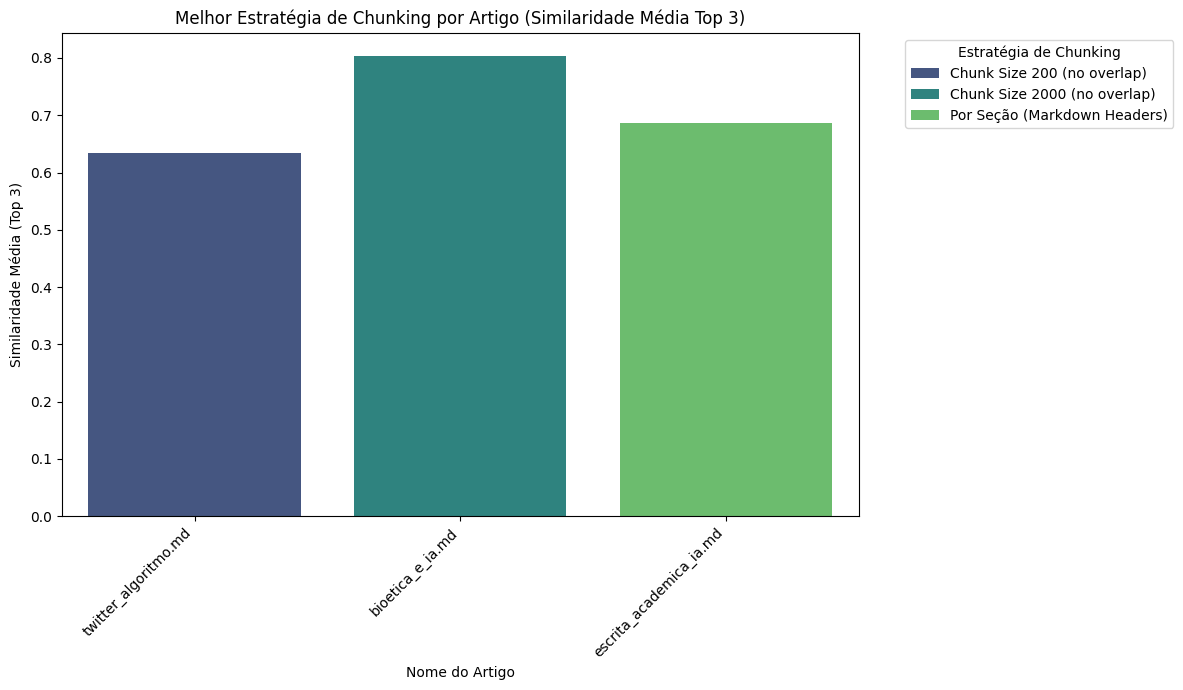

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare os dados para o gráfico
plot_data = []
for article_name, details in best_strategies_per_article.items():
    plot_data.append({
        'Artigo': article_name,
        'Melhor Estratégia': details['strategy_name'],
        'Similaridade Média (Top 3)': details['average_similarity']
    })

df_plot = pd.DataFrame(plot_data)

# Crie o gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Artigo',
    y='Similaridade Média (Top 3)',
    hue='Melhor Estratégia',
    data=df_plot,
    palette='viridis'
)

plt.title('Melhor Estratégia de Chunking por Artigo (Similaridade Média Top 3)')
plt.xlabel('Nome do Artigo')
plt.ylabel('Similaridade Média (Top 3)')
plt.xticks(rotation=45, ha='right') # Rotaciona os rótulos do eixo x para melhor legibilidade
plt.legend(title='Estratégia de Chunking', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Com base na análise das similaridades médias (Top 3) para cada artigo, as melhores estratégias de *chunking* para representar os documentos em um sistema de RAG são:

*   Para o artigo **`twitter_algoritmo.md`**:
    *   **Melhor Estratégia**: `Chunk Size 200 (no overlap)`
    

*   Para o artigo **`bioetica_e_ia.md`**:
    *   **Melhor Estratégia**: `Chunk Size 2000 (no overlap)`
    

*   Para o artigo **`escrita_academica_ia.md`**:
    *   **Melhor Estratégia**: `Por Seção (Markdown Headers)`
    

Isso sugere que não existe uma única "melhor" estratégia de *chunking* universal; a escolha ideal pode depender das características específicas de cada documento e do tipo de informação que se busca recuperar.